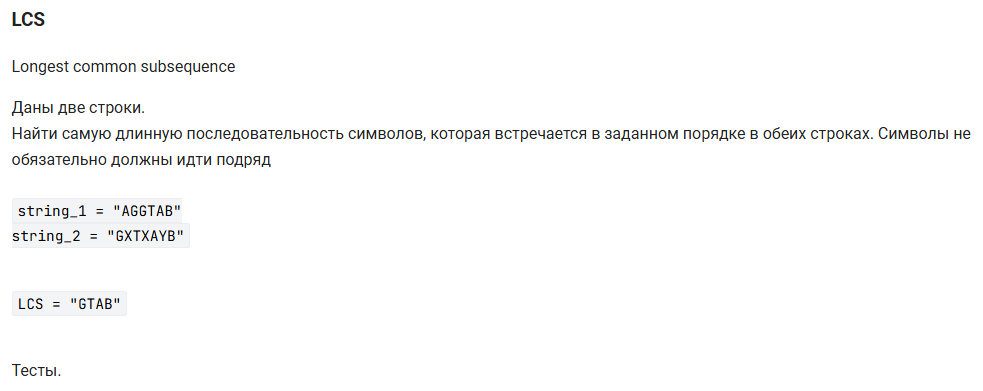

In [1]:
# Нахождение самой длинной подпоследовательности в вдух строках
def get_lcs(string_1, string_2):
    
    m = len(string_1)
    n = len(string_2)

    # Матрица для хранения длин LCS
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Заполнение матрицы
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if string_1[i - 1] == string_2[j - 1]:
                # Если символы совпадают, берем значение по диагонали + 1
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                # Если не совпадают, берем максимум из соседа сверху или слева
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    # Длина самой длинной подпоследовательности находится в dp[m][n]
    index = dp[m][n]
    lcs_list = [""] * (index + 1) # Временный массив символов
    lcs_str = ""

    i, j = m, n
    while i > 0 and j > 0:
        # Если символы равны, значит этот символ является частью LCS
        if string_1[i - 1] == string_2[j - 1]:
            lcs_str = string_1[i - 1] + lcs_str
            i -= 1
            j -= 1
        # Иначе движемся в сторону большего значения
        elif dp[i - 1][j] > dp[i][j - 1]:
            i -= 1
        else:
            j -= 1

    return lcs_str

In [2]:
# Тесты
if __name__ == "__main__":

    # Базовый пример из задания
    string_1 = "AGGTAB"
    string_2 = "GXTXAYB"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'GTAB'

    # Полное совпадение строк
    string_1 = "abcdef"
    string_2 = "abcdef"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'abcdef'

    # Полное отсутствие общих символов
    string_1 = "abc"
    string_2 = "xyz"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # ''

    # Одна строка является подпоследовательностью другой (без пропусков)
    string_1 = "hello world"
    string_2 = "world"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'world'

    # Подпоследовательность с пропусками символов
    string_1 = "a1b2c3d4"
    string_2 = "abcd"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'abcd'

    # Пустая строка
    string_1 = "something"
    string_2 = ""
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # ''

    # Общего порядка нет, кроме отдельных букв. Алгоритм вернет последнюю совпавшую букву
    string_1 = "ABC"
    string_2 = "CBA"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'C'

    # Работа с Unicode/Кириллицей
    string_1 = "Программирование"
    string_2 = "Погода"
    lcs = get_lcs(string_1, string_2)
    print(f"'{lcs}'")  # 'Пога'

'GTAB'
'abcdef'
''
'world'
'abcd'
''
'C'
'Погоа'
